# Lab 1: Intro to RS

## Section 1: Load Data

#### We will use the Movielens 10 million dataset (https://grouplens.org/datasets/movielens/10m/)

In [1]:
import os
import zipfile
from urllib.request import urlretrieve

In [2]:
# If file exists, skip the download
data_file_path = "movielens/Movielens10M/"
data_file_name = data_file_path + "movielens_10m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("http://files.grouplens.org/datasets/movielens/ml-10m.zip", data_file_name)

In [3]:
# unzip and read the ratings.dat file
dataFile = zipfile.ZipFile(data_file_path + "movielens_10m.zip")

mv_path = dataFile.extract("ml-10M100K/ratings.dat", path = data_file_path)

#### Let's take a look at the data

In [4]:
import pandas as pd

In [5]:
# sep="::" because file structure on website says is UserID::MovieID::Rating::Timestamp
# dtype={0:int, 1:int, 2:float, 3:int} is based on each column data type
mv_df = pd.read_csv(filepath_or_buffer=mv_path, sep="::", header=None, dtype={0:int, 1:int, 2:float, 3:int}, engine='python')

mv_df.columns = ["UserID", "ItemID", "Interaction", "Timestamp"]

In [6]:
mv_df.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,1,122,5.0,838985046
1,1,185,5.0,838983525
2,1,231,5.0,838983392
3,1,292,5.0,838983421
4,1,316,5.0,838983392
5,1,329,5.0,838983392
6,1,355,5.0,838984474
7,1,356,5.0,838983653
8,1,362,5.0,838984885
9,1,364,5.0,838983707


In [7]:
print("The number of interactions is {}".format(len(mv_df)))

The number of interactions is 10000054


#### We will now create a sparse matrix

<u>Note</u> : we read UserID and ItemID as int, but this is not always the case if the IDs are alphanumeric

#### Let's extract the list of unique user id and item id, and show some statistics to understand our data

In [8]:
userID_unique = mv_df['UserID'].unique()
itemID_unique = mv_df['ItemID'].unique()

In [9]:
n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(mv_df)

print("Number of users: {}\t, Number of items: {}".format(n_users, n_items))
# print largest IDs
print("Largest UserID: {}\t, Largest ItemID: {}".format(max(userID_unique), max(itemID_unique)))

Number of users: 69878	, Number of items: 10677
Largest UserID: 71567	, Largest ItemID: 65133


#### We observe that the max ID of users and items is higher than the number of unique users and items. Thus, we have some empty profiles

#### We should remove those empty indices, by creating a new mapping

In [10]:
mapped_id, original_id = pd.factorize(mv_df['UserID'].unique())
user_original_ID_to_index = pd.Series(mapped_id, index=original_id)

mapped_id, original_id = pd.factorize(mv_df['ItemID'].unique())
item_original_ID_to_index = pd.Series(mapped_id, index=original_id)

In [11]:
user_original_ID_to_index

1            0
2            1
3            2
4            3
5            4
         ...  
71563    69873
71564    69874
71565    69875
71566    69876
71567    69877
Length: 69878, dtype: int64

In [12]:
item_original_ID_to_index

122          0
185          1
231          2
292          3
316          4
         ...  
7537     10672
63481    10673
64652    10674
64427    10675
63662    10676
Length: 10677, dtype: int64

In [13]:
original_item_ID = 292
print("New index for item {} is {}".format(original_item_ID, item_original_ID_to_index[original_item_ID]))

New index for item 292 is 3


## Section 2: Replacing the IDs in the dataframe and we are ready to use the data

In [14]:
# .map() returns the index of the caller, so if the caller is UserID, the index is the original User ID, which was set earlier
mv_df["UserID"] = mv_df['UserID'].map(user_original_ID_to_index)
mv_df["ItemID"] = mv_df['ItemID'].map(item_original_ID_to_index)

In [16]:
mv_df.head(n=10)

,UserID,ItemID,Interaction,Timestamp
0,0,0,5.0,838985046
1,0,1,5.0,838983525
2,0,2,5.0,838983392
3,0,3,5.0,838983421
4,0,4,5.0,838983392
5,0,5,5.0,838983392
6,0,6,5.0,838984474
7,0,7,5.0,838983653
8,0,8,5.0,838984885
9,0,9,5.0,838983707


In [20]:
userID_unique = mv_df["UserID"].unique()
itemID_unique = mv_df["ItemID"].unique()

n_users = len(userID_unique)
n_items = len(itemID_unique)
n_interactions = len(mv_df)

print("Number of users: {}\t, Number of items: {}".format(n_users, n_items))
print("Max UserID: {}\t, Max ItemID: {}\n".format(max(userID_unique), max(itemID_unique)))

print("Average interactions per user: {:.2f}".format(n_interactions/n_users))
print("Average interactions per item: {:.2f}\n".format(n_interactions/n_items))

print("Sparsity {:.2f} %".format((1-float(n_interactions)/(n_users*n_items))*100))

Number of users: 69878	, Number of items: 10677
Max UserID: 69877	, Max ItemID: 10676

Average interactions per user: 143.11
Average interactions per item: 936.60

Sparsity 98.66 %


#### Rating distribution in time

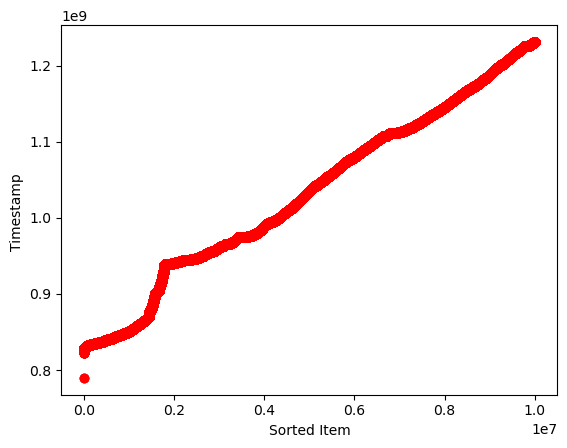

In [23]:
import matplotlib.pyplot as pyplot

# !!! Clone the list to avoid changing the ordering of the original data, best practice
timestamp_sorted = mv_df['Timestamp'].values.copy()
timestamp_sorted.sort()

pyplot.plot(timestamp_sorted, 'ro')
pyplot.ylabel('Timestamp ')
pyplot.xlabel('Sorted Item')
pyplot.show()

#### We use a sparse matrix to store the data. We build it as a COO matrix and then change its format

#### The COO constructor expects (data, (row, column))

In [25]:
import scipy.sparse as sps

mv_all = sps.coo_matrix((mv_df['Interaction'].values, (mv_df['UserID'].values, mv_df['ItemID'].values)))

mv_all

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 10000054 stored elements in COOrdinate format>

In [27]:
mv_all.tocsr()

<69878x10677 sparse matrix of type '<class 'numpy.float64'>'
	with 10000054 stored elements in Compressed Sparse Row format>

#### We compute the item popularity as the number of interaction in each column

#### We can use the properties of sparse matrices in CSC format

In [28]:
import numpy as np

# indptr stands for index pointer and is a property of the CSC
# 
item_popularity = np.ediff1d(mv_all.tocsc().indptr)
item_popularity

array([ 2412, 14975, 17851, ...,     1,     1,     1])

In [29]:
item_popularity = np.sort(item_popularity)
item_popularity

array([    1,     1,     1, ..., 33668, 34457, 34864])

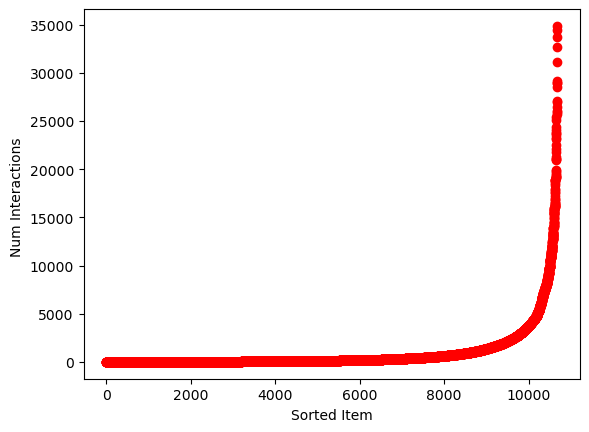

In [30]:
pyplot.plot(item_popularity, 'ro')
pyplot.ylabel('Num Interactions ')
pyplot.xlabel('Sorted Item')
pyplot.show()

In [ ]:
ten_percent = int(n_items/10)

print("Average per-item interactions over the whole dataset: {:.2f}". #FILL IN

print("Average per-item interactions for the top 10% popular items: {:.2f}". #FILL IN

print("Average per-item interactions for the least 10% popular items: {:.2f}". #FILL IN

print("Average per-item interactions for the median 10% popular items: {:.2f}". #FILL IN

In [ ]:
print("Number of items with zero interactions {}" #FILL IN

#### We compute the user activity (profile length) as the number of interaction in each row

#### We can use the properties of sparse matrices in CSR format

In [ ]:
user_activity = #FILL IN
user_activity = np.sort(user_activity)

pyplot.plot(user_activity, 'ro')
pyplot.ylabel('Num Interactions ')
pyplot.xlabel('Sorted User')
pyplot.show()

## Section 3: Evaluation

#### In order to evaluate our recommender, we have to:
* Split the data into mv_train and mv_test (i.e., train and test set)
* Define evaluation metrics
* Define a functon to compute the evaluation for each user

##### <u>Note</u>: The splitting of the data is very important to ensure your algorithm is evaluated appropriately

In [ ]:
train_test_split = 0.80

n_interactions = mv_all.nnz


train_mask = np.random.choice([True, False], n_interactions, p=[train_test_split, 1-train_test_split])
train_mask

In [ ]:
mv_train = #FILL IN -- hint: use sps.csr_matrix()

mv_train

In [ ]:
test_mask = np.logical_not(train_mask)

mv_test = #FILL IN -- hint: similar to mv_train above

mv_test

#### We call items in the test set 'relevant'

In [ ]:
user_id = 124
relevant_items = #FILL IN -- hint: get indices of user 124 from mv_test
relevant_items

#### Assume that we have a recommendation list such as:

In [ ]:
recommended_items = np.array([241, 1622, 15, 857, 5823])
recommended_items

In [ ]:
is_relevant = #FILL IN -- hint: use np.in1d to check the difference between two lists: recommended_items and relevant_items
is_relevant

#### Precision: how many of the recommended items are relevant

In [ ]:
def precision(recommended_items, relevant_items):

    is_relevant = #FILL IN

    precision_score = #FILL IN -- hint: check the definition of precision

    return precision_score

#### Recall: how many of the relevant items I was able to recommend

In [ ]:
def recall(recommended_items, relevant_items):

    is_relevant = #FILL IN

    recall_score = #FILL IN -- hint: check the definition of recall

    return recall_score

#### Average Precision

In [ ]:
def AP(recommended_items, relevant_items):

    is_relevant = #FILL IN -- hint: don't look at the 'solutions' above

    # Cumulative sum: precision at 1, at 2, at 3 ...
    p_at_k = is_relevant * np.cumsum(is_relevant, dtype=np.float32) / (1 + np.arange(is_relevant.shape[0]))

    ap_score = np.sum(p_at_k) / np.min([relevant_items.shape[0], is_relevant.shape[0]])

    return ap_score

#### Now that we have the data, we can build our first recommender. We need two things:
* a 'fit' function to train our model
* a 'recommend' function that uses our model to recommend

## Section 4: Let's start with a random recommender

#### In a random recommender, we don't learn anything from the data

In [ ]:
class RandomRecommender(object):

    def fit(self, mv_train):

        self.n_items = mv_train.shape[1]


    def recommend(self, user_id, at=5):

        recommended_items = #FILL IN -- hint: check numpy random choice function

        return recommended_items

(Optional) Homework: Improve RandomRecommender such as the recommended list doesn't contain item 235 (because this item is not good to recommend to the users)

In [ ]:
randomRecommender = RandomRecommender()
randomRecommender.fit(mv_train)

for user_id in range(10):
    print(#FILL IN -- hint: use .recommend() that's already implemented above

#### Put all together in an evaluation function and let's test it!

In [ ]:
# We pass the recommender class as paramether

def evaluate_algorithm(mv_test, recommender_object, at=5):

    cumulative_precision = 0.0
    cumulative_recall = 0.0
    cumulative_AP = 0.0

    num_eval = 0


    for user_id in range(mv_test.shape[0]):

        relevant_items = #FILL IN -- hint: get from mv_test.indices[x:y]

        if len(relevant_items)>0:

            recommended_items = recommender_object.recommend(user_id, at=at)
            num_eval += 1

            cumulative_precision += #FILL IN
            cumulative_recall += #FILL IN
            cumulative_AP += #FILL IN

    cumulative_precision /= num_eval
    cumulative_recall /= num_eval
    MAP = cumulative_AP / num_eval

    print("Recommender results are: Precision = {:.4f}, Recall = {:.4f}, MAP = {:.4f}".format(
        cumulative_precision, cumulative_recall, MAP))


In [ ]:
evaluate_algorithm(#FILL IN

### Yay! We have our first recommender. The recommendation quality however...

# End of Lab!

References:

[1] Surprise: A Python scikit for recommender systems (https://surpriselib.com/)

[2] Programming Collective Intelligence. Toby Segaran 2007.

[3] RecSys Lab @ Polimi